In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("credit card.csv")
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [3]:
print("---Shape of the dataset---")
rows, cols = df.shape
print(f"No. of rows: {rows}")
print(f"No. of columns: {cols}")


---Shape of the dataset---
No. of rows: 30000
No. of columns: 25


In [4]:
df.isna().sum()

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

In [6]:
df.duplicated().sum()

0

In [7]:
df.rename(columns={"default.payment.next.month": "Payment"}, inplace=True)


In [8]:
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'Payment'],
      dtype='object')

In [9]:
x = df.drop(["ID","Payment"],axis = 1)
y = df[["Payment"]]

## Feature Selection

In [11]:
## Wrapper Method
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

In [12]:
lr = LogisticRegression(class_weight="balanced", random_state=42)

In [13]:
y.value_counts()

Payment
0          23364
1           6636
Name: count, dtype: int64

In [14]:
from sklearn.model_selection import train_test_split as tts
xtrain, xtest, ytrain, ytest = tts(x,y,test_size=0.20, random_state = 42)
lr.fit(xtrain,ytrain)

C:\Users\Qbits\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\Qbits\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced', random_state=42)

In [15]:
xtrain.shape

(24000, 23)

In [16]:
xtest.shape

(6000, 23)

In [17]:
ytrain.shape

(24000, 1)

In [18]:
ytest.shape

(6000, 1)

In [19]:
model_lr = RFE(lr, n_features_to_select=10)

In [20]:
model_lr

RFE(estimator=LogisticRegression(class_weight='balanced', random_state=42),
    n_features_to_select=10)

In [21]:
model_lr.fit(xtrain,ytrain)

C:\Users\Qbits\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\Qbits\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\Qbits\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example us

RFE(estimator=LogisticRegression(class_weight='balanced', random_state=42),
    n_features_to_select=10)

In [22]:
model_lr.score(xtrain,ytrain)*100

73.4

In [23]:
sel_fea = xtrain.columns[model_lr.support_]
sel_fea

Index(['SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3',
       'PAY_4', 'PAY_5', 'PAY_6'],
      dtype='object')

In [24]:
rank = model_lr.ranking_
rank

array([ 9,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  6,  7, 14, 13,  8, 12,
        3,  2,  5,  4, 11, 10])

In [25]:
for feature, ranks in zip(xtrain.columns, rank):
    print(f"{feature} : {ranks}")

LIMIT_BAL : 9
SEX : 1
EDUCATION : 1
MARRIAGE : 1
AGE : 1
PAY_0 : 1
PAY_2 : 1
PAY_3 : 1
PAY_4 : 1
PAY_5 : 1
PAY_6 : 1
BILL_AMT1 : 6
BILL_AMT2 : 7
BILL_AMT3 : 14
BILL_AMT4 : 13
BILL_AMT5 : 8
BILL_AMT6 : 12
PAY_AMT1 : 3
PAY_AMT2 : 2
PAY_AMT3 : 5
PAY_AMT4 : 4
PAY_AMT5 : 11
PAY_AMT6 : 10


In [26]:
# Make a separate dataset based on the features which have ranked 1

In [27]:
# Embedded method
# Create a Logistic Regression model using L1 regularization (Lasso) with the 'liblinear' solver
model_lr2 = LogisticRegression(penalty="l1", solver="liblinear")

In [28]:
model_lr2.fit(xtrain,ytrain)

C:\Users\Qbits\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression(penalty='l1', solver='liblinear')

In [29]:
coef = model_lr2.coef_
coef

array([[-8.26588626e-07, -1.17254546e-01, -9.88593343e-02,
        -1.55309353e-01,  8.06001516e-03,  5.75960707e-01,
         9.04700511e-02,  6.49036257e-02,  4.51756462e-02,
         1.82126991e-02,  1.41951899e-02, -5.07822404e-06,
         2.01279873e-06,  1.55471353e-06, -8.86596790e-07,
         6.65832027e-07,  3.85786294e-07, -1.03203462e-05,
        -1.02097814e-05, -1.37249988e-06, -3.43692004e-06,
        -1.40307263e-06, -2.75577438e-06]])

In [30]:
for feature, coe in zip(xtrain.columns, coef[0]):
    print(f"{feature} : {coe}")

LIMIT_BAL : -8.265886255787889e-07
SEX : -0.11725454565615354
EDUCATION : -0.09885933430151089
MARRIAGE : -0.15530935258867112
AGE : 0.008060015163527902
PAY_0 : 0.5759607065602058
PAY_2 : 0.09047005105268152
PAY_3 : 0.0649036256508555
PAY_4 : 0.045175646188713246
PAY_5 : 0.018212699070820557
PAY_6 : 0.014195189889338928
BILL_AMT1 : -5.078224041041363e-06
BILL_AMT2 : 2.0127987265507026e-06
BILL_AMT3 : 1.55471353059589e-06
BILL_AMT4 : -8.86596789536546e-07
BILL_AMT5 : 6.65832027220529e-07
BILL_AMT6 : 3.8578629385391076e-07
PAY_AMT1 : -1.0320346181935758e-05
PAY_AMT2 : -1.0209781431352775e-05
PAY_AMT3 : -1.3724998772474955e-06
PAY_AMT4 : -3.436920037066043e-06
PAY_AMT5 : -1.403072629393086e-06
PAY_AMT6 : -2.7557743810616124e-06


In [31]:
# Filter method
from sklearn.ensemble import ExtraTreesClassifier
etc = ExtraTreesClassifier()
etc.fit(xtrain,ytrain)

C:\Users\Qbits\anaconda3\Lib\site-packages\sklearn\base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


ExtraTreesClassifier()

In [32]:
etc.feature_importances_


array([0.06588451, 0.01198309, 0.03246035, 0.02143998, 0.06608247,
       0.09483935, 0.05148513, 0.0360493 , 0.03275213, 0.03043639,
       0.028279  , 0.04964438, 0.04656882, 0.0444112 , 0.0441448 ,
       0.04314333, 0.04353242, 0.0436512 , 0.04227349, 0.0417319 ,
       0.04109963, 0.04262374, 0.04548338])

In [33]:
# Make a dataframe
feature_sel = pd.DataFrame(etc.feature_importances_, columns = ['Importance'])
feature_sel

,Importance
0,0.065885
1,0.011983
2,0.032460
3,0.021440
4,0.066082
5,0.094839
6,0.051485
7,0.036049
8,0.032752
9,0.030436


In [34]:
cols2 = pd.DataFrame(x.columns, columns = ['Columns'])
cols2

,Columns
0,LIMIT_BAL
1,SEX
2,EDUCATION
3,MARRIAGE
4,AGE
5,PAY_0
6,PAY_2
7,PAY_3
8,PAY_4
9,PAY_5


In [35]:
new = pd.concat([cols2,feature_sel],axis = 1)
new

,Columns,Importance
0,LIMIT_BAL,0.065885
1,SEX,0.011983
2,EDUCATION,0.032460
3,MARRIAGE,0.021440
4,AGE,0.066082
5,PAY_0,0.094839
6,PAY_2,0.051485
7,PAY_3,0.036049
8,PAY_4,0.032752
9,PAY_5,0.030436


In [36]:
new_col = new.nlargest(10, "Importance")
new_col

,Columns,Importance
5,PAY_0,0.094839
4,AGE,0.066082
0,LIMIT_BAL,0.065885
6,PAY_2,0.051485
11,BILL_AMT1,0.049644
12,BILL_AMT2,0.046569
22,PAY_AMT6,0.045483
13,BILL_AMT3,0.044411
14,BILL_AMT4,0.044145
17,PAY_AMT1,0.043651


<Axes: >

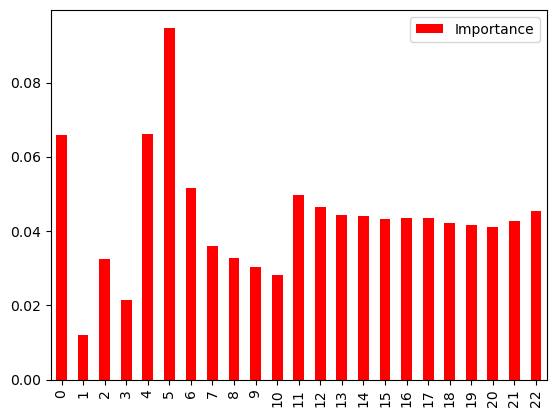

In [37]:
new.plot(kind="bar", color="r")

<Axes: >

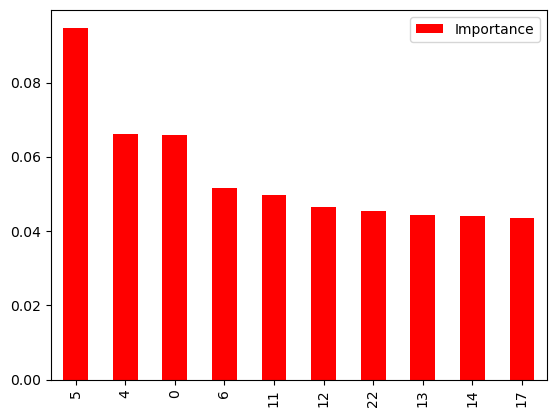

In [38]:
new_col.plot(kind="bar", color="r")

In [77]:
# K - best approach

In [79]:
from sklearn.feature_selection import f_classif, chi2, f_regression, SelectKBest

In [81]:
kb = SelectKBest(score_func = f_classif, k=10)

In [83]:
feature_score = kb.fit(xtrain,ytrain)
feature_score

C:\Users\Qbits\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SelectKBest()

In [85]:
feature_score.scores_

array([5.85511064e+02, 4.46122538e+01, 2.18379119e+01, 1.36314180e+01,
       7.00920731e+00, 2.85054942e+03, 1.83951397e+03, 1.44450043e+03,
       1.23161051e+03, 1.05347696e+03, 8.87619651e+02, 8.94098450e+00,
       4.55464429e+00, 4.96353021e+00, 2.88864408e+00, 1.35279548e+00,
       7.02420464e-01, 1.11262198e+02, 7.67962823e+01, 6.97052928e+01,
       7.03089721e+01, 5.94365913e+01, 7.27847877e+01])

In [93]:
scor = pd.DataFrame(feature_score.scores_, columns=['Feature Score'])
cols3 = pd.DataFrame(xtrain.columns, columns=['Columns'])

In [95]:
join = pd.concat([cols3, scor],axis=1)
join

,Columns,Feature Score
0,LIMIT_BAL,585.511064
1,SEX,44.612254
2,EDUCATION,21.837912
3,MARRIAGE,13.631418
4,AGE,7.009207
5,PAY_0,2850.549420
6,PAY_2,1839.513969
7,PAY_3,1444.500432
8,PAY_4,1231.610511
9,PAY_5,1053.476961


In [105]:
join_lar = join.nlargest(10,'Feature Score')
join_lar

,Columns,Feature Score
5,PAY_0,2850.549420
6,PAY_2,1839.513969
7,PAY_3,1444.500432
8,PAY_4,1231.610511
9,PAY_5,1053.476961
10,PAY_6,887.619651
0,LIMIT_BAL,585.511064
17,PAY_AMT1,111.262198
18,PAY_AMT2,76.796282
22,PAY_AMT6,72.784788


<Axes: >

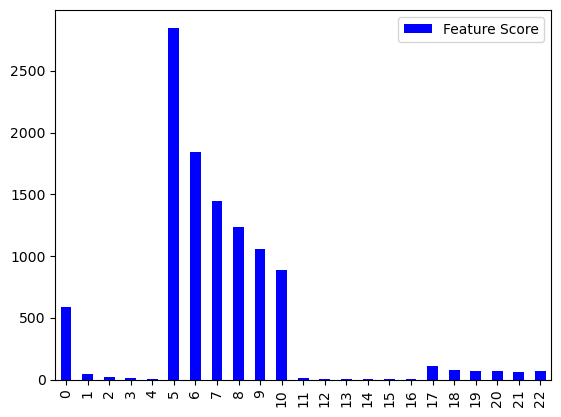

In [103]:
join.plot(kind="bar",color='b')

<Axes: >

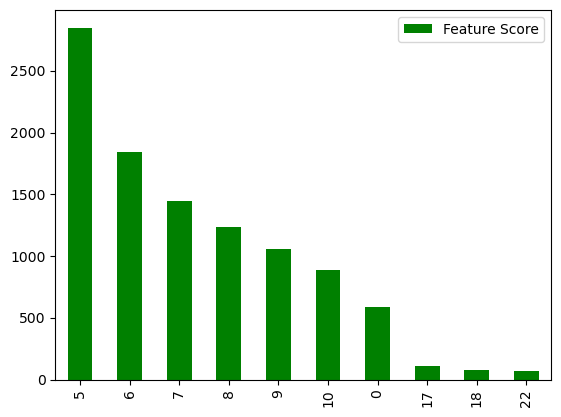

In [107]:
join_lar.plot(kind='bar',color='g')